# WEEK-4 Project: **Data Visualization**

### Topic: **Monthly Expense Analysis of a Person**

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 

Loading the Dataset and Performing Initial Inspection

In [3]:
df  = pd.read_csv('data/myExpenses1.csv')

In [4]:
print(f"      FIRST 5 ROWS:  \n{df.head()}")
print(f"\nSHAPE OF DATSET :\n\n  {df.shape}")
print(f"\nDATA TYPES OF EACH COLUMN:\n ")
print(df.dtypes)

      FIRST 5 ROWS:  
       Date     Item  Amount Category   Time        day
0  1/3/2023     chai       7    alone   7:00  Wednesday
1  1/3/2023     chai      20   friend  10:00  Wednesday
2  1/3/2023    juice      15   friend  13:00  Wednesday
3  1/3/2023  rikshow      12    alone  14:00  Wednesday
4  1/3/2023   coffee      12    alone  15:00  Wednesday

SHAPE OF DATSET :

  (145, 6)

DATA TYPES OF EACH COLUMN:
 
Date          str
Item          str
Amount      int64
Category      str
Time          str
day           str
dtype: object


**Checking for NULL values and Elminating it.**

In [5]:
print(df.isna().sum())

Date        0
Item        0
Amount      0
Category    1
Time        0
day         0
dtype: int64


Printing the Row which has NULL value: 

In [6]:
print("printing the NULL row: \n" , df[df['Category'].isna()])

printing the NULL row: 
          Date    Item  Amount Category   Time     day
72  12/3/2023  others      10      NaN  18:30  Sunday


Due to  only one NULL. We will drop that row:

In [7]:
df.dropna(inplace=True)
df.isna().sum()

Date        0
Item        0
Amount      0
Category    0
Time        0
day         0
dtype: int64

Copying the orignal dataset to new.(Which is a good habit)

In [8]:
df1 = df.copy(deep=True)

### FINDING SOME METRICS. 
(total_spent, Avg_spent, Total_spent with friends and when alone)

In [9]:
total_spent = df1['Amount'].sum()
avg_spent =  df1['Amount'].mean()
frndTotal_spent = df1[df1['Category']== 'friend']['Amount'].sum()
aloneTotal_spent = df1[df1['Category']== 'alone']['Amount'].sum()

Top 3 Highest spent item, when alone and with friends

In [10]:
alone_top3 = df1[df1['Category'] =='alone'].groupby('Item',as_index=0)['Amount'].sum().sort_values(by = 'Amount',ascending=False).head(3)
frnd_top3 = df1[df1['Category'] =='friend'].groupby('Item', as_index=0)['Amount'].sum().sort_values(by = 'Amount',ascending=False).head(3)

Finally printing all the Calculated Metrics

In [11]:
print("CALCULATE METRICS:")
print("=" * 40)

print(f"{'TOTAL SPENT:':30} ₹ {total_spent}")
print(f"{'AVERAGE SPENT:':30} ₹ {avg_spent}")
print(f"{'TOTAL SPENT when Alone:':30} ₹ {aloneTotal_spent}")
print(f"{'TOTAL SPENT with Friends:':30} ₹ {frndTotal_spent}")

print("\nTOP 3 highest items when with Friends:")
print("-" * 40)
print(frnd_top3.to_string(index=False))

print("\nTOP 3 highest items when Alone:")
print("-" * 40)
print(alone_top3.to_string(index=False))

CALCULATE METRICS:
TOTAL SPENT:                   ₹ 4599
AVERAGE SPENT:                 ₹ 31.9375
TOTAL SPENT when Alone:        ₹ 2710
TOTAL SPENT with Friends:      ₹ 1889

TOP 3 highest items when with Friends:
----------------------------------------
   Item  Amount
biryani     580
  juice     195
chicken     180

TOP 3 highest items when Alone:
----------------------------------------
           Item  Amount
chai with snaks    1065
           shoe     500
           wifi     350


## **Visualizations of the Data:**

#### BAR CHART for Visualizing the **TOP 3** Highest Spent ITEMs by Category.

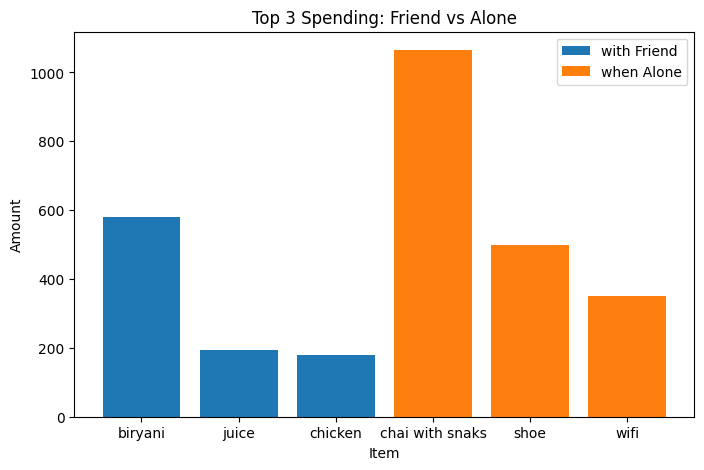

In [16]:

plt.figure(figsize=(8,5))

plt.bar(frnd_top3['Item'], frnd_top3['Amount'], label='with Friend')
plt.bar(alone_top3['Item'], alone_top3['Amount'], label='when Alone')

plt.legend()
plt.xlabel('Item')
plt.ylabel('Amount')
plt.title('Top 3 Spending: Friend vs Alone')

plt.show()

#### PIE CHART to visualize the Total Spent by Category.

Text(0.5, 1.0, 'Expenses By Category')

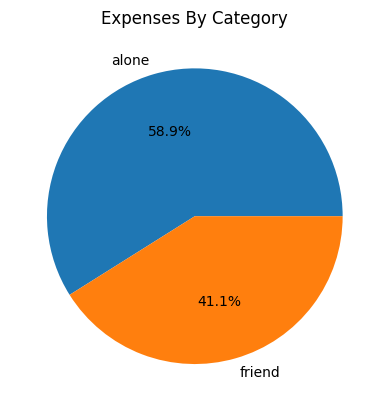

In [13]:
cat_spent = df1.groupby('Category')["Amount"].sum()

plt.Figure(figsize=(8,5))

cat_spent.plot.pie(autopct='%1.1f%%')
plt.title("Expenses By Category")